# Audit de Biais et Analyse des Proxys

L'objectif de ce rapport est de diagnostiquer le biais du modèle de base et d'identifier
les variables qui servent de proxys à la variable sensible `region_administrative`.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from fairlearn.metrics import (
    MetricFrame,
    demographic_parity_difference,
    selection_rate,
    true_positive_rate,
)

# 1. Chargement des données
demandes = pd.read_csv('data/donnees_demandes.csv')
candidats = pd.read_csv('data/candidats_evaluation.csv')

# Regroupement des régions comme dans le baseline
ELOIGNEES = ['Bas-Saint-Laurent', 'Cote-Nord', 'Gaspesie-Iles-de-la-Madeleine']
def groupe_region(df):
    return np.where(df['region_administrative'].isin(ELOIGNEES), 'Eloignee', 'Centre')

demandes['groupe'] = groupe_region(demandes)
print(f"Données chargées : {len(demandes)} dossiers")

Données chargées : 10000 dossiers


## Analyse de la Distribution

In [2]:
print("--- Distribution des candidatures par groupe ---")
dist_groupe = demandes['groupe'].value_counts(normalize=True) * 100
counts_groupe = demandes['groupe'].value_counts()
print(pd.DataFrame({'Nombre': counts_groupe, 'Pourcentage (%)': dist_groupe}))

--- Distribution des candidatures par groupe ---
          Nombre  Pourcentage (%)
groupe                           
Centre      6000             60.0
Eloignee    4000             40.0


In [3]:
print("--- Taux d'octroi par groupe ---")
taux_octroi_groupe = demandes.groupby('groupe')['decision_octroi'].mean() * 100
print(taux_octroi_groupe.map("{:.2f}%".format))

--- Taux d'octroi par groupe ---
groupe
Centre      48.37%
Eloignee    27.30%
Name: decision_octroi, dtype: str


In [4]:
print("--- Distribution détaillée par région ---")
dist_region = demandes['region_administrative'].value_counts(normalize=True) * 100
counts_region = demandes['region_administrative'].value_counts()
print(pd.DataFrame({'Nombre': counts_region, 'Pourcentage (%)': dist_region}))

--- Distribution détaillée par région ---
                               Nombre  Pourcentage (%)
region_administrative                                 
Montreal                         4001            40.01
Capitale-Nationale               1999            19.99
Gaspesie-Iles-de-la-Madeleine    1529            15.29
Bas-Saint-Laurent                1293            12.93
Cote-Nord                        1178            11.78


## Analyse des Proxys

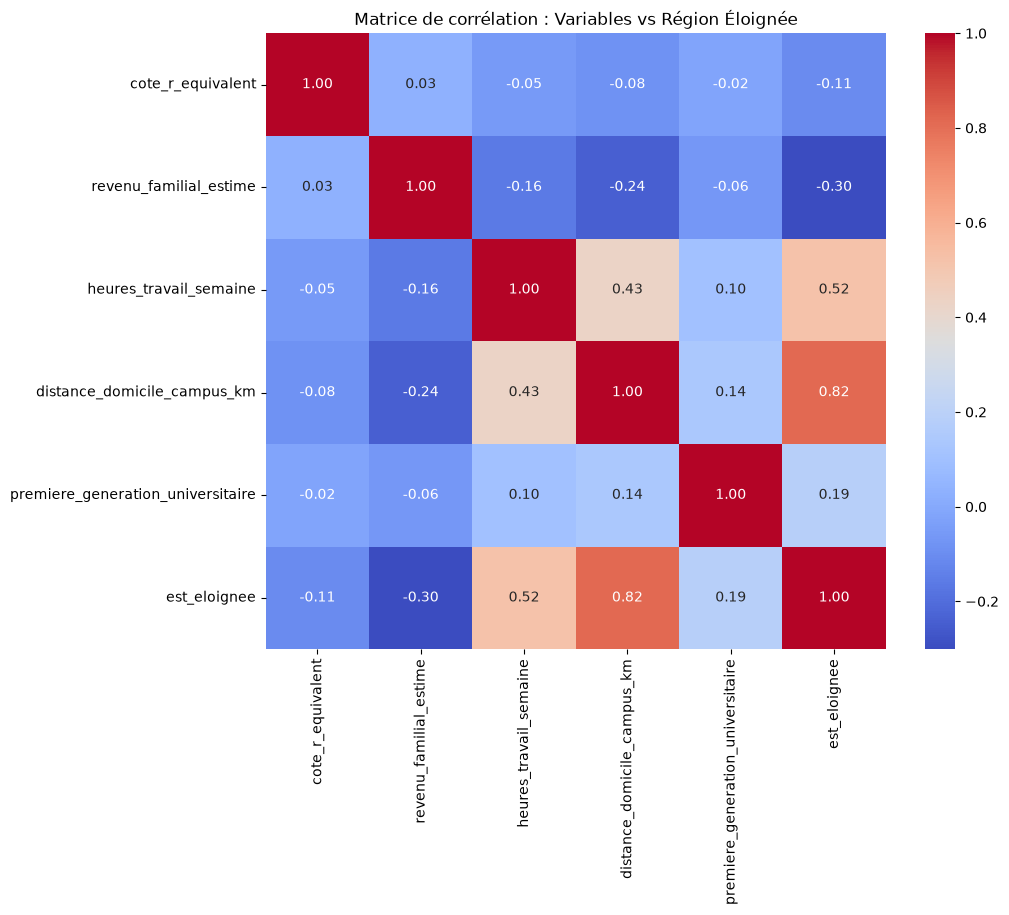


Corrélation avec la variable 'est_eloignee' :
est_eloignee                         1.000000
distance_domicile_campus_km          0.815899
heures_travail_semaine               0.521010
premiere_generation_universitaire    0.185759
cote_r_equivalent                   -0.107680
revenu_familial_estime              -0.301169
Name: est_eloignee, dtype: float64


In [5]:
demandes['est_eloignee'] = (demandes['groupe'] == 'Eloignee').astype(int)
cols_numeriques = ['cote_r_equivalent', 'revenu_familial_estime', 'heures_travail_semaine', 'distance_domicile_campus_km', 'premiere_generation_universitaire', 'est_eloignee']
corr_matrix_region = demandes[cols_numeriques].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix_region, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matrice de corrélation : Variables vs Région Éloignée")
plt.show()
print("\nCorrélation avec la variable 'est_eloignee' :")
print(corr_matrix_region['est_eloignee'].sort_values(ascending=False))

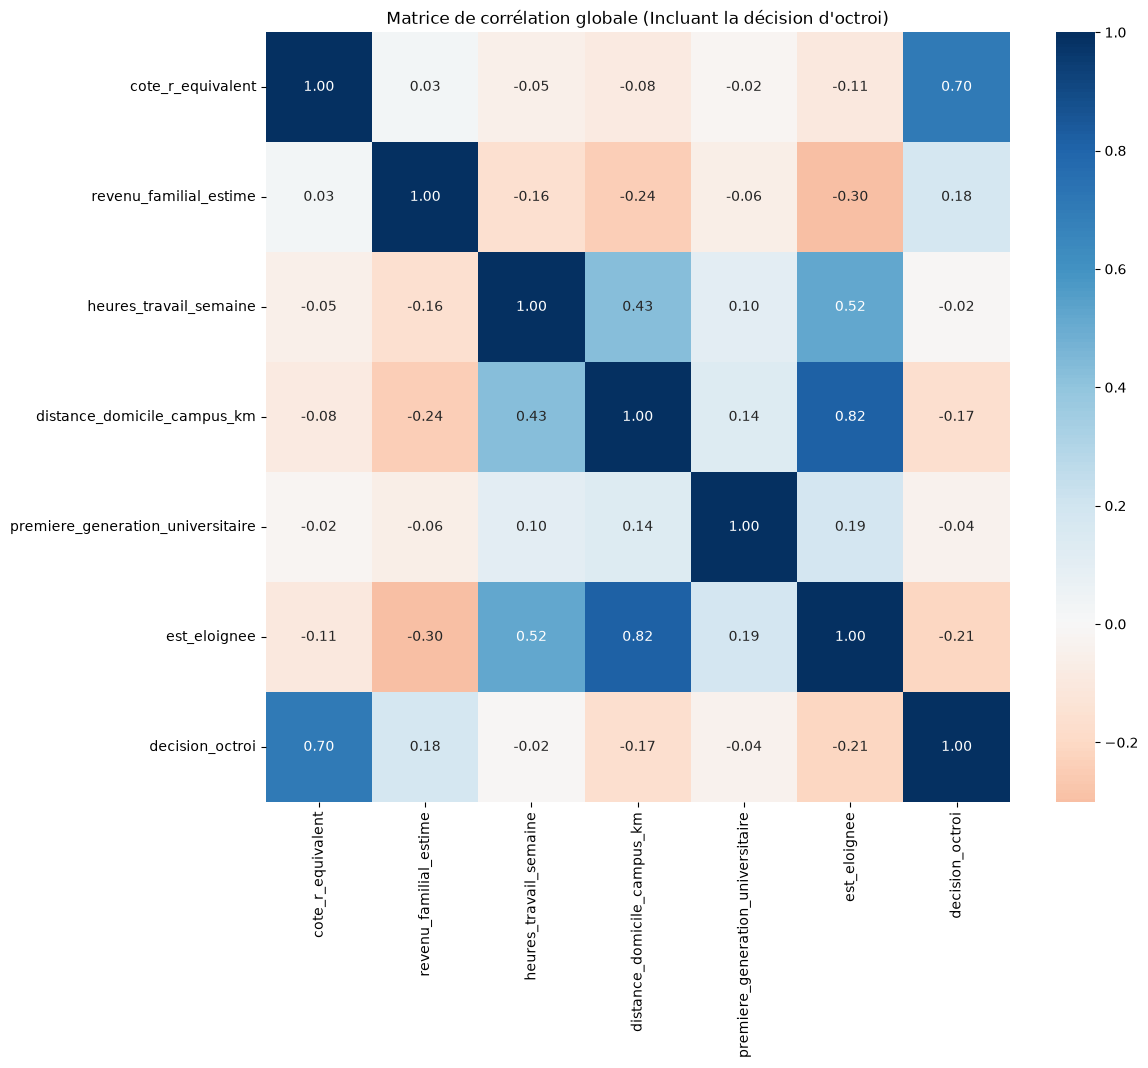


Corrélation globale avec 'decision_octroi' :
decision_octroi                      1.000000
cote_r_equivalent                    0.701419
revenu_familial_estime               0.177562
heures_travail_semaine              -0.016494
premiere_generation_universitaire   -0.037585
distance_domicile_campus_km         -0.165163
est_eloignee                        -0.210720
Name: decision_octroi, dtype: float64


In [6]:
cols_toutes = cols_numeriques + ['decision_octroi']
corr_matrix_all = demandes[cols_toutes].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix_all, annot=True, cmap='RdBu', center=0, fmt=".2f")
plt.title("Matrice de corrélation globale (Incluant la décision d'octroi)")
plt.show()
print("\nCorrélation globale avec 'decision_octroi' :")
print(corr_matrix_all['decision_octroi'].sort_values(ascending=False))

## Audit non supervisé : DBSCAN, HDBSCAN et Isolation Forest

Cet audit est **descriptif**. Une observation isolée n'est ni un dossier invalide ni une décision erronée. Les prédictions ayant obtenu **94,6 % d'accuracy sur HxBuddy** sont conservées. Les métriques HxBuddy sont indicatives et distinctes de la grille IVADO, comme l'indiquent les consignes PDF.

Les détecteurs utilisent cote R, heures de travail, log du revenu et log de la distance. Le centrage-réduction et les détecteurs sont ajustés uniquement sur les 10 000 dossiers historiques ; les étiquettes, identifiants et catégories géographiques sont exclus des distances. Le transfert DBSCAN vers les nouveaux dossiers est une règle explicite : cœur d'entraînement le plus proche dans le rayon epsilon, sinon non assigné.

**Résultats :** DBSCAN signale 108 des 4 000 candidats (2,70 %), dont 61 sélectionnés et seulement 4 proches du seuil. Isolation Forest en signale 216 (5,40 %). Les deux méthodes signalent davantage les régions éloignées. HDBSCAN retrouve deux groupes presque entièrement régionaux à partir des proxys, mais laisse 61,47 % des dossiers historiques non assignés.

La validation sur cinq plis historiques n'apporte aucun gain significatif : baseline 88,72 %, exclusion Isolation Forest 88,73 %, exclusion DBSCAN 88,67 %, variable de cluster DBSCAN 88,68 %. **Ces accuracies concernent les décisions du comité et ne mesurent pas la référence cachée.** Après réestimation du coefficient de travail, les deux variantes DBSCAN produisent exactement les mêmes décisions finales ; la variante Isolation Forest n'en modifie que deux.

Conséquence : conserver les indicateurs pour l'audit et la surveillance, sans supprimer automatiquement les dossiers. Rapport détaillé : `density_audit_report.md`. Régénération : `python audit_density.py`, `python research/audit_hdbscan.py`, `python research/validate_density.py`.


In [ ]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Image

audit_dir = Path('audit_results')
if not audit_dir.exists():
    audit_dir = Path('equialgo-participants/audit_results')
with (audit_dir / 'density_audit.json').open() as f:
    density_results = json.load(f)
display(pd.read_csv(audit_dir / 'flag_rates_by_group.csv'))
with (audit_dir / 'density_validation_results.json').open() as f:
    validation = json.load(f)
comparison = pd.DataFrame({
    name: result['historical_classifier_oof']
    for name, result in validation['results'].items()
}).T[['accuracy', 'f1_macro', 'eop_gap']]
display(comparison)
display(Image(filename=str(audit_dir / 'density_audit.png')))
